# Latihan

**Fundamen Sains Data — Latihan Bagian A sampai C**
Program Studi Informatika, Program Sarjana, Universitas Islam Indonesia

Kerjakan latihan berikut di notebook Google Colab baru. Tuliskan interpretasi setiap hasil di text cell
tepat di bawah code cell yang bersangkutan, lalu jalankan **Runtime > Restart session and run all** sebelum
mengumpulkan untuk memastikan notebook berjalan tanpa galat.

Notebook ini memuat **penyelesaian** keempat latihan sebagai acuan. Kerjakan sendiri terlebih dahulu,
lalu bandingkan hasil dan interpretasinya.

---
## Latihan 1 — Eksplorasi data dengan pandas dan Matplotlib

Buat DataFrame berisi 10 mahasiswa dengan kolom `nama`, `durasi_belajar` (jam per minggu), dan `nilai`.
Hitung rata-rata kedua kolom numerik, filter mahasiswa yang durasi belajarnya di atas rata-rata, dan buat
diagram pencar durasi belajar terhadap nilai lengkap dengan judul dan label sumbu. Jelaskan apakah pola
pada grafik menunjukkan hubungan positif, negatif, atau tidak jelas.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_latihan = pd.DataFrame({
    "nama": ["Ani", "Budi", "Citra", "Dodi", "Eka",
             "Fajar", "Gita", "Hana", "Indra", "Joko"],
    "durasi_belajar": [4, 6, 8, 3, 10, 7, 5, 9, 2, 6],
    "nilai": [62, 70, 81, 58, 92, 76, 68, 88, 55, 72],
})

print(df_latihan)
print("Rata-rata durasi belajar:", round(df_latihan["durasi_belajar"].mean(), 2), "jam per minggu")
print("Rata-rata nilai         :", round(df_latihan["nilai"].mean(), 2))
print("Rata-rata durasi belajar (NumPy):", round(np.mean(df_latihan["durasi_belajar"]), 2))

di_atas_rata = df_latihan[df_latihan["durasi_belajar"] > df_latihan["durasi_belajar"].mean()]
print("\nMahasiswa dengan durasi belajar di atas rata-rata:")
print(di_atas_rata[["nama", "durasi_belajar", "nilai"]].to_string(index=False))

    nama  durasi_belajar  nilai
0    Ani               4     62
1   Budi               6     70
2  Citra               8     81
3   Dodi               3     58
4    Eka              10     92
5  Fajar               7     76
6   Gita               5     68
7   Hana               9     88
8  Indra               2     55
9   Joko               6     72
Rata-rata durasi belajar: 6.0 jam per minggu
Rata-rata nilai         : 72.2
Rata-rata durasi belajar (NumPy): 6.0

Mahasiswa dengan durasi belajar di atas rata-rata:
 nama  durasi_belajar  nilai
Citra               8     81
  Eka              10     92
Fajar               7     76
 Hana               9     88


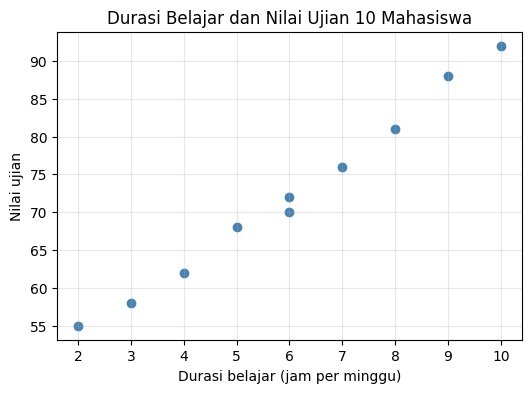

In [2]:
plt.figure(figsize=(6, 4))
plt.scatter(df_latihan["durasi_belajar"], df_latihan["nilai"], color="steelblue")
plt.title("Durasi Belajar dan Nilai Ujian 10 Mahasiswa")
plt.xlabel("Durasi belajar (jam per minggu)")
plt.ylabel("Nilai ujian")
plt.grid(alpha=0.3)
plt.show()

**Penjelasan.** Pola titik pada diagram pencar naik dari kiri bawah ke kanan atas, sehingga hubungan antara
durasi belajar dan nilai adalah **positif**: mahasiswa yang belajar lebih lama cenderung memperoleh nilai
lebih tinggi. Rata-rata durasi belajar adalah 6.0 jam per minggu dengan rata-rata nilai 72.2. Empat mahasiswa
(Citra, Eka, Fajar, Hana) belajar di atas rata-rata, dan sebagian besar dari mereka bernilai di atas
rata-rata kelas, meskipun Fajar menjadi pengecualian. Seperti pada Bagian B, hubungan positif tidak otomatis
berarti sebab-akibat.

---
## Latihan 2 — Statistik deskriptif dan pengaruh pencilan

Gunakan array `nilai_ujian` dari C.0. Hitung mean, median, modus, standar deviasi sampel, $Q_1$, $Q_3$, dan
IQR. Kemudian ubah nilai terendah (55) menjadi 15, hitung ulang semua ukuran tersebut beserta batas pencilan
rumus (7), lalu buat histogram dan boxplot data yang sudah diubah. Jelaskan ukuran mana yang berubah banyak,
ukuran mana yang hampir tidak berubah, dan apa artinya bagi pemilihan mean atau median sebagai ukuran pusat data.

### Bagian 1 — sebelum pengubahan

In [3]:
def ringkasan_statistik(data, label):
    seri = pd.Series(data, name="nilai_ujian")
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    print(f"--- {label} ---")
    print(f"Mean        : {np.mean(data):.2f}")
    print(f"Median      : {np.median(data):.2f}")
    print(f"Modus       : {seri.mode().tolist()}")
    print(f"Std (sampel): {np.std(data, ddof=1):.2f}")
    print(f"Q1, Q3      : {q1:.2f}, {q3:.2f}  (IQR = {iqr:.2f})")
    print(f"Batas pencilan: {q1 - 1.5 * iqr:.2f} sampai {q3 + 1.5 * iqr:.2f}")
    pencilan = data[(data < q1 - 1.5 * iqr) | (data > q3 + 1.5 * iqr)]
    print(f"Pencilan    : {pencilan}")


nilai_ujian = np.array([55, 60, 62, 65, 68, 70, 70, 72, 75, 76,
                        78, 80, 82, 82, 85, 88, 90, 92, 95, 98])

ringkasan_statistik(nilai_ujian, "Data asli (20 mahasiswa)")

--- Data asli (20 mahasiswa) ---
Mean        : 77.15
Median      : 77.00
Modus       : [70, 82]
Std (sampel): 12.04
Q1, Q3      : 69.50, 85.75  (IQR = 16.25)
Batas pencilan: 45.12 sampai 110.12
Pencilan    : []


### Bagian 2 — setelah nilai terendah diubah menjadi 15

In [4]:
nilai_ubah = nilai_ujian.copy()
nilai_ubah[nilai_ubah == 55] = 15      # nilai terendah diubah menjadi 15

ringkasan_statistik(nilai_ubah, "Data dengan nilai 55 diubah menjadi 15")

--- Data dengan nilai 55 diubah menjadi 15 ---
Mean        : 75.15
Median      : 77.00
Modus       : [70, 82]
Std (sampel): 17.84
Q1, Q3      : 69.50, 85.75  (IQR = 16.25)
Batas pencilan: 45.12 sampai 110.12
Pencilan    : [15]


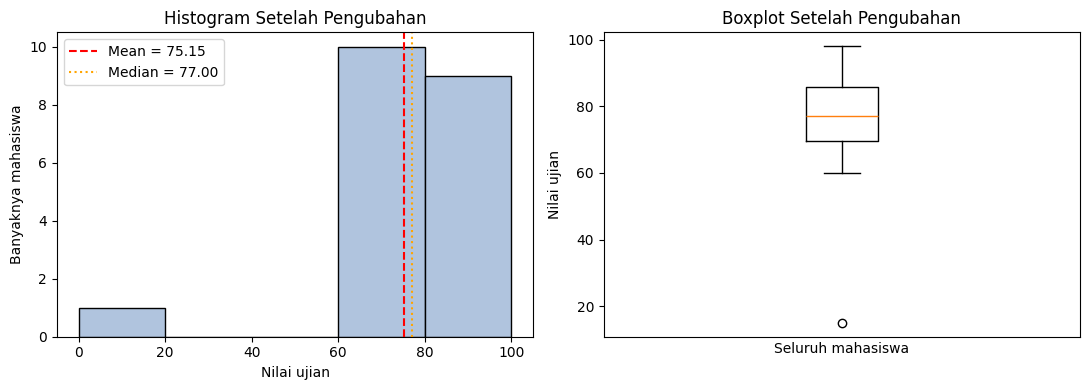

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(nilai_ubah, bins=[0, 20, 40, 60, 80, 100],
             color="lightsteelblue", edgecolor="black")
axes[0].axvline(np.mean(nilai_ubah), color="red", linestyle="--",
                label=f"Mean = {np.mean(nilai_ubah):.2f}")
axes[0].axvline(np.median(nilai_ubah), color="orange", linestyle=":",
                label=f"Median = {np.median(nilai_ubah):.2f}")
axes[0].set_title("Histogram Setelah Pengubahan")
axes[0].set_xlabel("Nilai ujian")
axes[0].set_ylabel("Banyaknya mahasiswa")
axes[0].legend()

axes[1].boxplot(nilai_ubah)
axes[1].set_title("Boxplot Setelah Pengubahan")
axes[1].set_xlabel("Seluruh mahasiswa")
axes[1].set_ylabel("Nilai ujian")
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

**Penjelasan.**

- Ukuran yang **berubah**: mean turun dari **77.15** menjadi **75.15** (turun 2 poin, karena satu nilai
  berubah 40 poin lalu dibagi 20 mahasiswa), standar deviasi sampel naik dari **12.04** menjadi **17.84**,
  dan rentang melebar dari **43** menjadi **83**.
- Ukuran yang **hampir tidak berubah**: median tetap **77.00**, modus tetap **[70, 82]**, dan $Q_1$, $Q_3$,
  IQR, serta batas pencilan juga tetap (**16.25**; batas 45.12 sampai 110.12) — nilai 15 berada di bawah
  $Q_1$, sehingga tidak menggeser posisi kuartil. Yang berubah adalah statusnya: nilai 15 kini muncul sebagai
  **pencilan**.

Artinya, **median (dan modus) lebih tahan terhadap pencilan (robust)**, sedangkan **mean mudah tertarik**
oleh nilai ekstrem. Untuk data yang diduga mengandung pencilan atau sangat miring, median lebih tepat dipakai
sebagai ukuran pusat; mean tetap berguna ketika data cukup simetris dan tidak berpencilan. Pada boxplot,
pergeseran nilai 55 menjadi 15 terlihat sebagai titik pencilan di bawah whisker, sementara kotak (Q1–Q3) dan
whisker atas tidak berubah.

---
## Latihan 3 — Simulasi probabilitas dan distribusi binomial

Sebuah kuis terdiri atas 10 soal pilihan ganda dengan 4 pilihan jawaban, dan seorang mahasiswa menjawab semua
soal dengan menebak secara acak. Gunakan `scipy.stats.binom` untuk menghitung probabilitas menjawab benar
tepat 3 soal, paling banyak 2 soal, dan paling sedikit 6 soal, lalu buat grafik PMF dan CDF. Kemudian
simulasikan 10.000 mahasiswa penebak dengan `np.random.default_rng(42)` dan bandingkan frekuensi relatif
"paling sedikit 6 benar" dengan probabilitas teoretisnya. Jelaskan mengapa puncak PMF tidak berada di tengah
seperti pada contoh koin di C.3.

In [6]:
from scipy.stats import binom

n_soal = 10
p_benar = 1 / 4          # 1 dari 4 pilihan jawaban

p_tepat_3 = binom.pmf(3, n_soal, p_benar)
p_maks_2 = binom.cdf(2, n_soal, p_benar)
p_min_6 = 1 - binom.cdf(5, n_soal, p_benar)

print(f"P(X = 3)  = {p_tepat_3:.4f}")
print(f"P(X <= 2) = {p_maks_2:.4f}")
print(f"P(X >= 6) = {p_min_6:.4f}")

P(X = 3)  = 0.2503
P(X <= 2) = 0.5256
P(X >= 6) = 0.0197


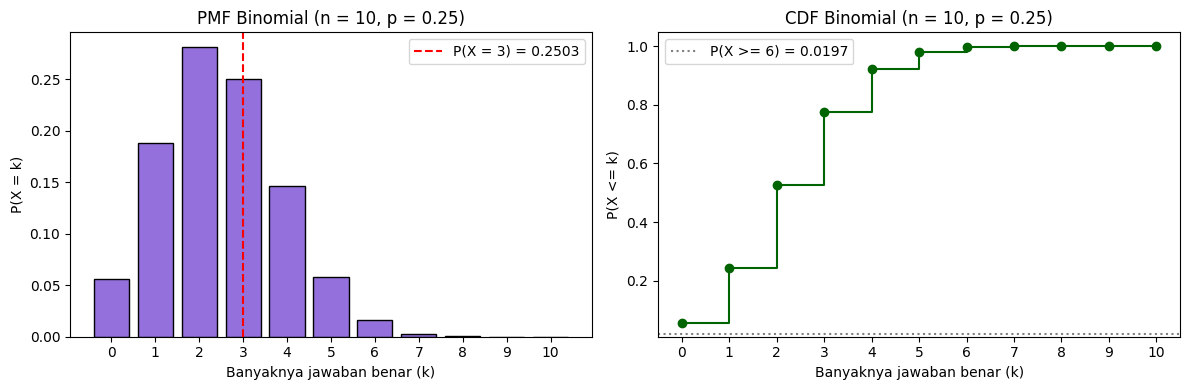

In [7]:
k_kuis = np.arange(0, n_soal + 1)
pmf_kuis = binom.pmf(k_kuis, n_soal, p_benar)
cdf_kuis = binom.cdf(k_kuis, n_soal, p_benar)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(k_kuis, pmf_kuis, color="mediumpurple", edgecolor="black")
axes[0].axvline(3, color="red", linestyle="--", label=f"P(X = 3) = {p_tepat_3:.4f}")
axes[0].set_title("PMF Binomial (n = 10, p = 0.25)")
axes[0].set_xlabel("Banyaknya jawaban benar (k)")
axes[0].set_ylabel("P(X = k)")
axes[0].set_xticks(k_kuis)
axes[0].legend()

axes[1].step(k_kuis, cdf_kuis, where="post", color="darkgreen")
axes[1].scatter(k_kuis, cdf_kuis, color="darkgreen", zorder=3)
axes[1].axhline(p_min_6, color="gray", linestyle=":",
                label=f"P(X >= 6) = {p_min_6:.4f}")
axes[1].set_title("CDF Binomial (n = 10, p = 0.25)")
axes[1].set_xlabel("Banyaknya jawaban benar (k)")
axes[1].set_ylabel("P(X <= k)")
axes[1].set_xticks(k_kuis)
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
# Simulasi 10.000 mahasiswa penebak
rng = np.random.default_rng(42)
banyak_mahasiswa = 10_000

# Setiap baris = satu mahasiswa, setiap kolom = satu soal.
# Setiap soal ditebak dengan peluang benar p_benar = 0.25 (pilihan ganda 4 jawaban).
jawaban_benar = rng.random((banyak_mahasiswa, n_soal)) < p_benar
jumlah_benar = jawaban_benar.sum(axis=1)

frekuensi_relatif = np.mean(jumlah_benar >= 6)
print(f"Frekuensi relatif P(X >= 6) dari simulasi : {frekuensi_relatif:.4f}")
print(f"Probabilitas teoretis P(X >= 6)           : {p_min_6:.4f}")
print(f"Selisih                                   : {abs(frekuensi_relatif - p_min_6):.4f}")
print("Rata-rata jawaban benar (simulasi):", round(jumlah_benar.mean(), 3),
      "| teoretis n*p =", round(n_soal * p_benar, 3))

Frekuensi relatif P(X >= 6) dari simulasi : 0.0195
Probabilitas teoretis P(X >= 6)           : 0.0197
Selisih                                   : 0.0002
Rata-rata jawaban benar (simulasi): 2.495 | teoretis n*p = 2.5


**Penjelasan.**

- Probabilitas menjawab benar tepat 3 soal adalah **0.2503**, paling banyak 2 soal **0.5256**, dan paling
  sedikit 6 soal **0.0197** — menebak 6 soal benar dari 10 termasuk kejadian yang jarang.
- Simulasi 10.000 penebak memberi frekuensi relatif **0.0195**, dekat dengan nilai teoretis 0.0197, dan
  rata-rata jawaban benar 2.495 dibanding nilai teoretisnya $np = 2{,}5$ — sesuai hukum bilangan besar pada
  C.2.3. Nilai simulasi bergantung pada seed; dengan seed lain angkanya bergeser sedikit.
- Puncak PMF berada di $k \approx n p = 10 \times 0{,}25 = 2{,}5$, yaitu di $k = 2$ dan $k = 3$, **bukan di
  tengah** seperti contoh koin. Contoh koin memakai $p = 0{,}5$, sehingga distribusinya simetris dan puncaknya
  jatuh di $n/2 = 5$. Untuk kuis ini $p$ jauh lebih kecil dari 0.5, sehingga sebaran **miring ke kanan**:
  peluang mendapat banyak jawaban benar kecil, dan sebagian besar nilai menumpuk di 0 sampai 4.

---
## Latihan 4 — Distribusi normal

Waktu tempuh mahasiswa dari tempat tinggal ke kampus dimodelkan dengan distribusi normal, mean 30 menit dan
standar deviasi 8 menit. Hitung probabilitas seorang mahasiswa memerlukan waktu kurang dari 20 menit, lebih
dari 45 menit, dan antara 25 sampai 35 menit, lalu gambarkan ketiganya sebagai daerah arsiran di bawah kurva
PDF. Hitung juga probabilitas waktu tempuh kurang dari 0 menit menurut model, dan jelaskan apa yang
ditunjukkan hasil tersebut tentang keterbatasan model normal untuk data ini.

In [9]:
from scipy.stats import norm

mu_tempuh = 30       # mean (menit)
sigma_tempuh = 8     # standar deviasi (menit)
model_tempuh = norm(loc=mu_tempuh, scale=sigma_tempuh)

p_kurang_20 = model_tempuh.cdf(20)
p_lebih_45 = model_tempuh.sf(45)
p_25_35 = model_tempuh.cdf(35) - model_tempuh.cdf(25)
p_kurang_0 = model_tempuh.cdf(0)

print(f"P(X < 20)         = {p_kurang_20:.4f}")
print(f"P(X > 45)         = {p_lebih_45:.4f}")
print(f"P(25 < X < 35)    = {p_25_35:.4f}")
print(f"P(X < 0)          = {p_kurang_0:.8f}")

P(X < 20)         = 0.1056
P(X > 45)         = 0.0304
P(25 < X < 35)    = 0.4680
P(X < 0)          = 0.00008842


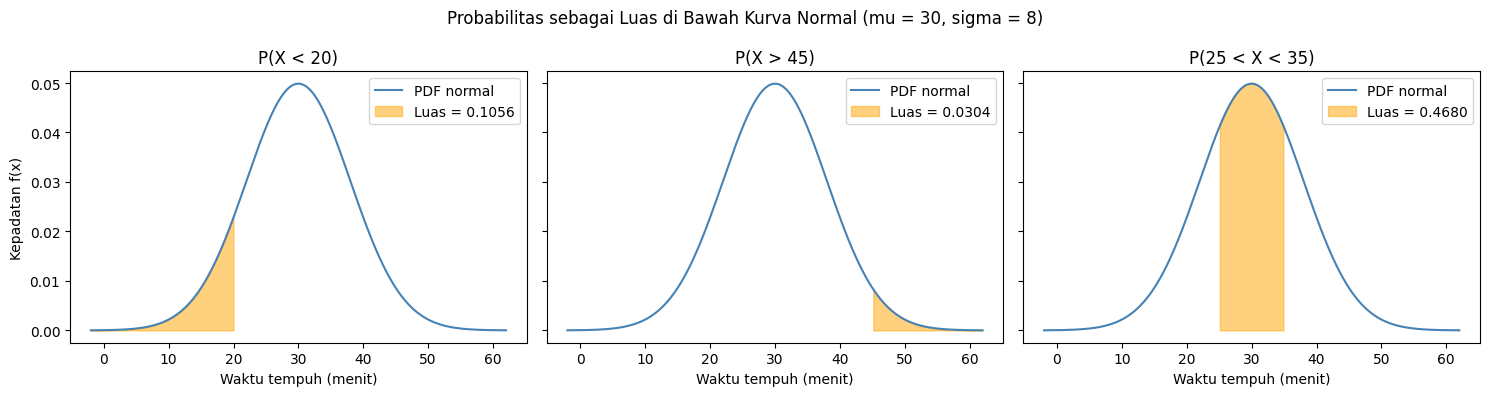

In [10]:
x_tempuh = np.linspace(mu_tempuh - 4 * sigma_tempuh, mu_tempuh + 4 * sigma_tempuh, 400)
pdf_tempuh = model_tempuh.pdf(x_tempuh)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
daftar = [
    ("P(X < 20)", x_tempuh <= 20, p_kurang_20),
    ("P(X > 45)", x_tempuh >= 45, p_lebih_45),
    ("P(25 < X < 35)", (x_tempuh >= 25) & (x_tempuh <= 35), p_25_35),
]

for ax, (judul, daerah, peluang) in zip(axes, daftar):
    ax.plot(x_tempuh, pdf_tempuh, color="steelblue", label="PDF normal")
    ax.fill_between(x_tempuh, pdf_tempuh, where=daerah, color="orange", alpha=0.5,
                    label=f"Luas = {peluang:.4f}")
    ax.set_title(judul)
    ax.set_xlabel("Waktu tempuh (menit)")
    ax.legend()
axes[0].set_ylabel("Kepadatan f(x)")

plt.suptitle("Probabilitas sebagai Luas di Bawah Kurva Normal (mu = 30, sigma = 8)")
plt.tight_layout()
plt.show()

**Penjelasan.**

- $P(X < 20) = 0.1056$: sekitar 10.56% mahasiswa memerlukan kurang dari 20 menit.
- $P(X > 45) = 0.0304$: sekitar 3.04% mahasiswa memerlukan lebih dari 45 menit.
- $P(25 < X < 35) = 0.4680$: hampir separuh mahasiswa memerlukan waktu antara 25 sampai 35 menit, sejalan
  dengan sifat distribusi normal bahwa sekitar 68% data berada dalam $\mu \pm 1\sigma$ (22 sampai 38 menit).
- $P(X < 0) = 0.00008842$: model memberi peluang sekitar 0.0088% untuk waktu tempuh **negatif**, padahal waktu
  tempuh mustahil bernilai negatif. Ini memperlihatkan keterbatasan model normal: meskipun kecil, peluang
  untuk nilai mustahil **tidak nol**, karena kurva normal memiliki ekor yang memanjang tanpa batas ke kedua
  arah. Penyebabnya adalah waktu tempuh memiliki batas bawah alami (0 menit) yang tidak dimiliki distribusi
  normal, dan sebaran waktu tempuh nyata umumnya miring ke kanan (beberapa mahasiswa sangat lama di jalan).